# Member 2 - Outlier Detection and Handling

**Student ID:** IT25102316
**Dataset:** Medical Insurance Dataset

## Selected Preprocessing Technique
Outlier detection and handling using the Interquartile Range (IQR) method.

## Explanation
Outliers are observations that are unusually far from the majority of the
dataset. Extreme observations can influence statistical analysis and some
machine learning algorithms.

The IQR method identifies potential outliers using the first quartile (Q1),
third quartile (Q3), and Interquartile Range.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

## Justification
BMI is a continuous numerical feature in the insurance dataset and may contain
extreme observations. Therefore, BMI is investigated for potential outliers.

Instead of automatically deleting complete customer records, extreme BMI values
will be capped at the IQR boundaries.

## EDA
Boxplots will be used before and after outlier handling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/raw/insurance.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


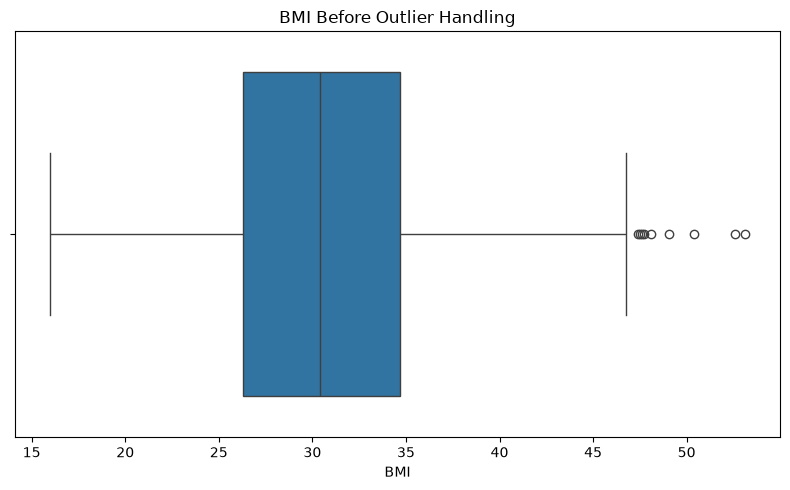

In [3]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["bmi"]
)

plt.title("BMI Before Outlier Handling")
plt.xlabel("BMI")

plt.tight_layout()

plt.savefig(
    "../results/eda_visualizations/member2_bmi_before.png"
)

plt.show()

In [4]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 26.29625
Q3: 34.69375
IQR: 8.3975
Lower Bound: 13.7
Upper Bound: 47.290000000000006


In [5]:
outliers = df[
    (df["bmi"] < lower_bound) |
    (df["bmi"] > upper_bound)
]

print(
    "Number of BMI Outliers:",
    len(outliers)
)

outliers.head()

Number of BMI Outliers: 9


,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520


In [6]:
df["bmi"] = df["bmi"].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("BMI outliers capped successfully.")

BMI outliers capped successfully.


In [7]:
remaining_outliers = (
    (df["bmi"] < lower_bound) |
    (df["bmi"] > upper_bound)
).sum()

print(
    "Remaining BMI Outliers:",
    remaining_outliers
)

Remaining BMI Outliers: 0


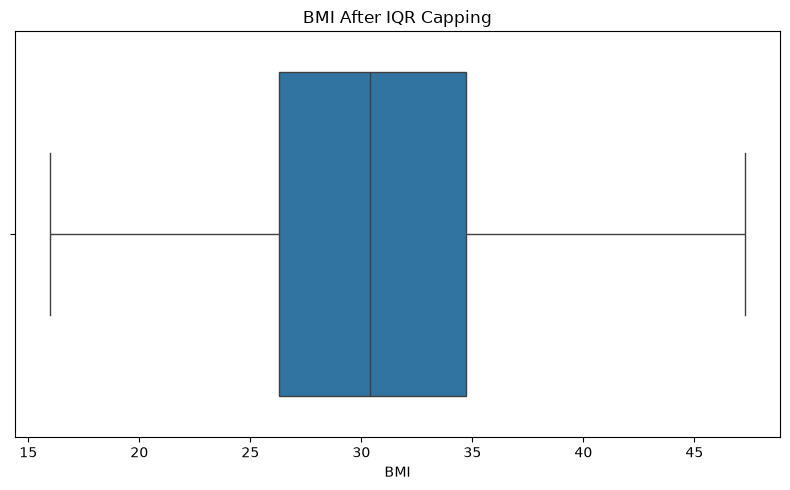

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["bmi"]
)

plt.title("BMI After IQR Capping")
plt.xlabel("BMI")

plt.tight_layout()

plt.savefig(
    "../results/eda_visualizations/member2_bmi_after.png"
)

plt.show()

## EDA Interpretation

The initial boxplot showed BMI observations outside the IQR boundaries.

The IQR method was used to identify these extreme observations. Instead of
deleting complete customer records, the extreme BMI values were capped at the
calculated boundaries.

This reduces the influence of extreme BMI values while retaining the remaining
information associated with each customer.

In [9]:
df.to_csv(
    "../results/outputs/member2_outlier_handled.csv",
    index=False
)

print("Member 2 output saved successfully.")

Member 2 output saved successfully.
